# **Final Project: Predicting Hospital Readmisson of Diabetics**

Objective: predict whether a diabetic inpatient will be readmitted within 30 days

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
#loading in the data
path = '/content/diabetic_data.csv'
df = pd.read_csv(path)
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.shape

(101766, 50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
#checking the target
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
df['readmitted'].value_counts(normalize=True)

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


In [ ]:
#the binary target
df['readmitted_30'] = np.where(df['readmitted'] == '<30', 1, 0)
df['readmitted_30'].value_counts()

,count
readmitted_30,
0,90409
1,11357


In [ ]:
df['readmitted_30'].value_counts(normalize=True)

,proportion
readmitted_30,
0,0.888401
1,0.111599


Data prep

In [ ]:
df = df.replace("?", np.nan)

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

missing_table[missing_table['missing_count'] > 0]

,missing_count,missing_percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [ ]:
cols_to_drop = [
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty'
]

df_clean = df.drop(columns=cols_to_drop)

In [ ]:
#drop the original multiclass target after creating the binary one
df_clean = df_clean.drop(columns=['readmitted'])

In [ ]:
#gender stuff
df_clean['gender'].value_counts()
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']

## **Exploratory Data Analysis**

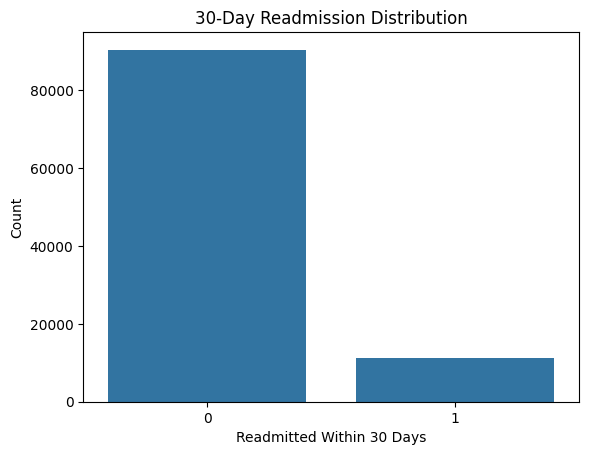

In [ ]:
sns.countplot(data=df_clean, x='readmitted_30')
plt.title('30-Day Readmission Distribution')
plt.xlabel('Readmitted Within 30 Days')
plt.ylabel('Count')
plt.show()

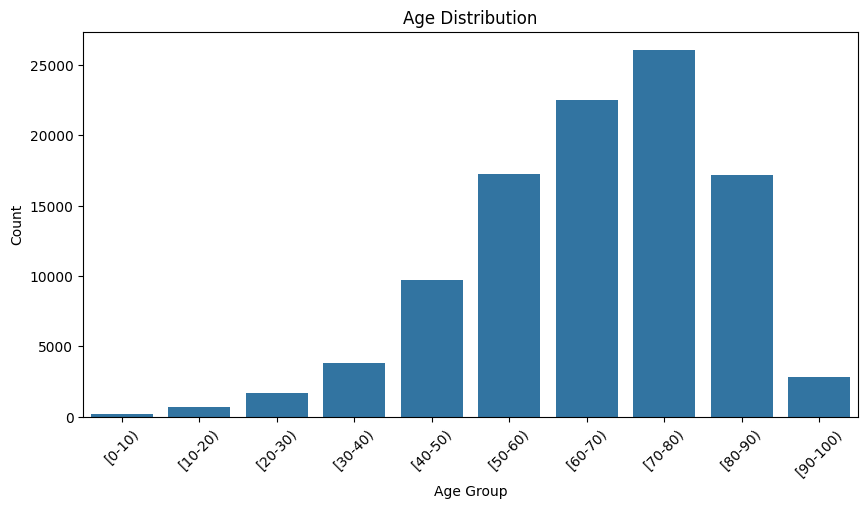

In [ ]:
#age distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='age', order=sorted(df_clean['age'].unique()))
plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

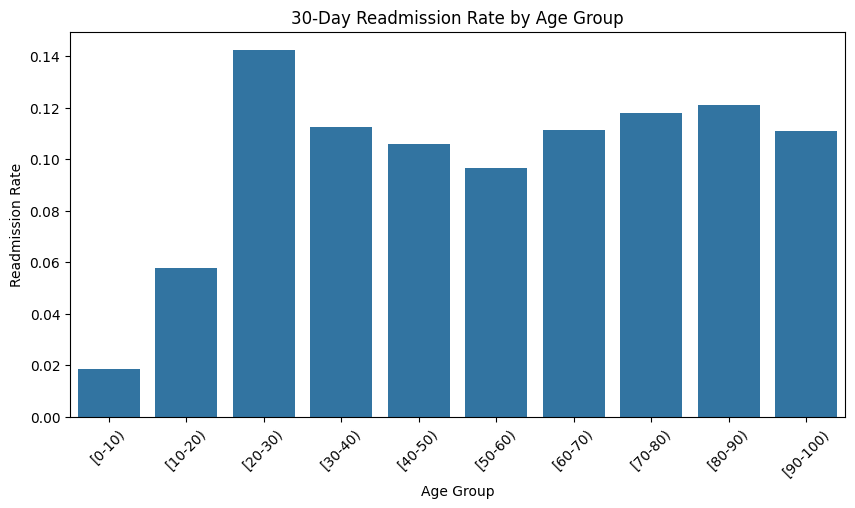

In [ ]:
#readmission by age
age_readmit = df_clean.groupby('age')['readmitted_30'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=age_readmit, x='age', y='readmitted_30')
plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)
plt.show()

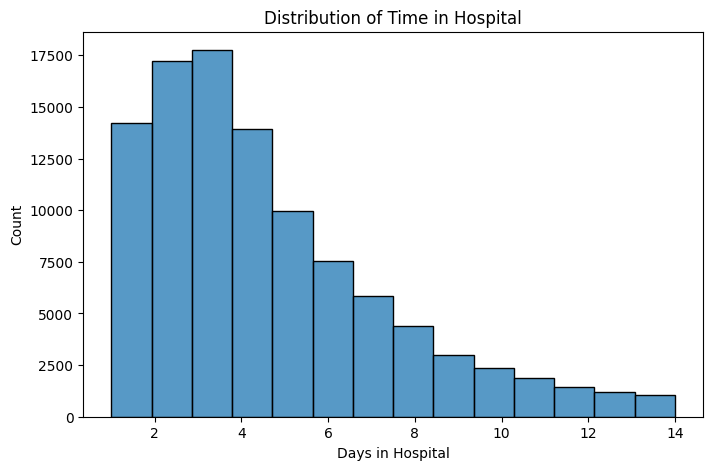

In [ ]:
#time in hospital
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='time_in_hospital', bins=14)
plt.title('Distribution of Time in Hospital')
plt.xlabel('Days in Hospital')
plt.ylabel('Count')
plt.show()

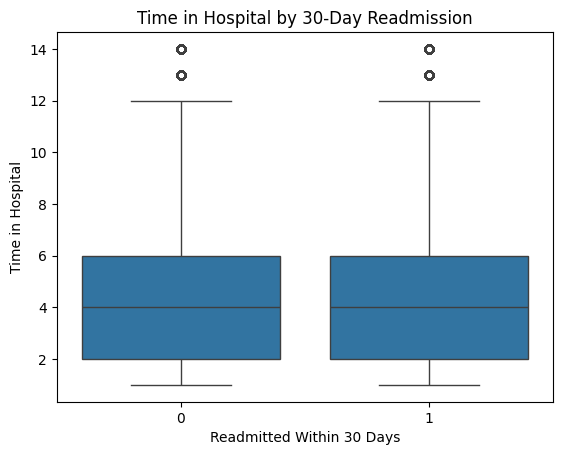

In [ ]:
sns.boxplot(data=df_clean, x='readmitted_30', y='time_in_hospital')
plt.title('Time in Hospital by 30-Day Readmission')
plt.xlabel('Readmitted Within 30 Days')
plt.ylabel('Time in Hospital')
plt.show()

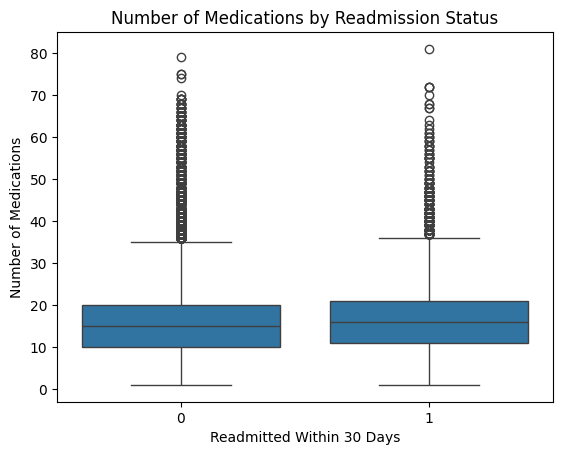

In [ ]:
#number of medications
sns.boxplot(data=df_clean, x='readmitted_30', y='num_medications')
plt.title('Number of Medications by Readmission Status')
plt.xlabel('Readmitted Within 30 Days')
plt.ylabel('Number of Medications')
plt.show()

In [ ]:
#A1 result
pd.crosstab(df_clean['A1Cresult'], df_clean['readmitted_30'], normalize='index')

readmitted_30,0,1
A1Cresult,,
>7,0.899528,0.100472
>8,0.901290,0.098710
Norm,0.903407,0.096593


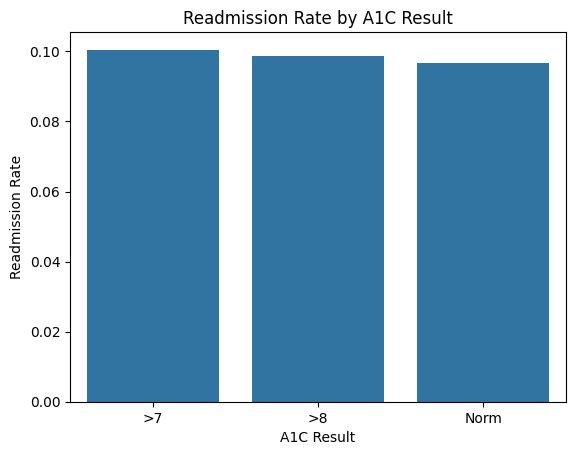

In [ ]:
a1c_readmit = df_clean.groupby('A1Cresult')['readmitted_30'].mean().reset_index()

sns.barplot(data=a1c_readmit, x='A1Cresult', y='readmitted_30')
plt.title('Readmission Rate by A1C Result')
plt.xlabel('A1C Result')
plt.ylabel('Readmission Rate')
plt.show()

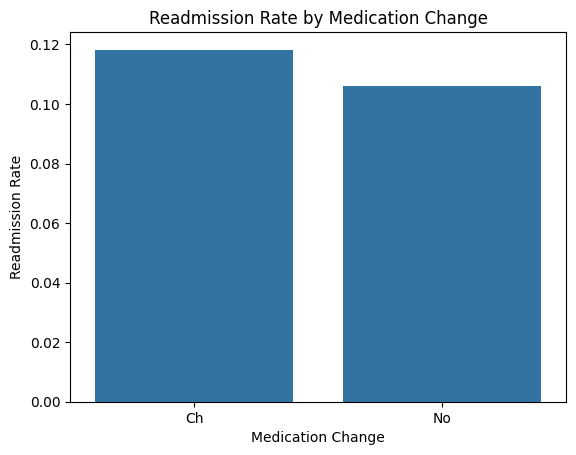

In [ ]:
#medication change
change_readmit = df_clean.groupby('change')['readmitted_30'].mean().reset_index()

sns.barplot(data=change_readmit, x='change', y='readmitted_30')
plt.title('Readmission Rate by Medication Change')
plt.xlabel('Medication Change')
plt.ylabel('Readmission Rate')
plt.show()

Medication features are important for this dataset because prior studies using this data have found that medication related variables can improve readmission prediction.

## **Feature Engineering**

In [ ]:
age_map = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

df_clean['age_midpoint'] = df_clean['age'].map(age_map)

In [ ]:
def map_diagnosis(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        code = float(code)

        if 390 <= code <= 459 or code == 785:
            return 'Circulatory'
        elif 460 <= code <= 519 or code == 786:
            return 'Respiratory'
        elif 520 <= code <= 579 or code == 787:
            return 'Digestive'
        elif 250 <= code < 251:
            return 'Diabetes'
        elif 800 <= code <= 999:
            return 'Injury'
        elif 710 <= code <= 739:
            return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788:
            return 'Genitourinary'
        elif 140 <= code <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Missing'

In [ ]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_group'] = df_clean[col].apply(map_diagnosis)

In [ ]:
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])

In [ ]:
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df_clean['num_med_changes'] = df_clean[med_cols].isin(['Up', 'Down']).sum(axis=1)
df_clean['num_meds_used'] = df_clean[med_cols].isin(['Steady', 'Up', 'Down']).sum(axis=1)

#Model Prep

In [ ]:
#separating features & target
X = df_clean.drop(columns=['readmitted_30'])
y = df_clean['readmitted_30']

In [ ]:
#identifying numeric & categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_features, categorical_features

(['admission_type_id',
  'discharge_disposition_id',
  'admission_source_id',
  'time_in_hospital',
  'num_lab_procedures',
  'num_procedures',
  'num_medications',
  'number_outpatient',
  'number_emergency',
  'number_inpatient',
  'number_diagnoses',
  'age_midpoint',
  'num_med_changes',
  'num_meds_used'],
 ['race',
  'gender',
  'age',
  'max_glu_serum',
  'A1Cresult',
  'metformin',
  'repaglinide',
  'nateglinide',
  'chlorpropamide',
  'glimepiride',
  'acetohexamide',
  'glipizide',
  'glyburide',
  'tolbutamide',
  'pioglitazone',
  'rosiglitazone',
  'acarbose',
  'miglitol',
  'troglitazone',
  'tolazamide',
  'examide',
  'citoglipton',
  'insulin',
  'glyburide-metformin',
  'glipizide-metformin',
  'glimepiride-pioglitazone',
  'metformin-rosiglitazone',
  'metformin-pioglitazone',
  'change',
  'diabetesMed',
  'diag_1_group',
  'diag_2_group',
  'diag_3_group'])

In [ ]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## **Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay


In [ ]:
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [ ]:
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change', 'diabetesMed', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

### Predictions:

In [ ]:
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

### Evaluation:

In [ ]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18082
           1       0.17      0.53      0.26      2271

    accuracy                           0.66     20353
   macro avg       0.55      0.61      0.52     20353
weighted avg       0.84      0.66      0.72     20353



In [ ]:
confusion_matrix(y_test, y_pred_log)

array([[12240,  5842],
       [ 1057,  1214]])

In [ ]:
roc_auc_score(y_test, y_prob_log)

np.float64(0.6493328182377349)

### ROC Curve:

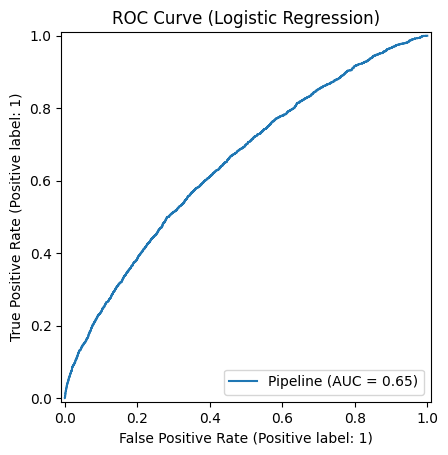

In [ ]:
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title('ROC Curve (Logistic Regression)')
plt.show()

Because the positive class is uncommon, we should emphasize recall, precision, F1-score, and ROC-AUC, not just accuracy.

## **Additional Models:**

## Decision-Tree:

In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

In [ ]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change', 'diabetesMed', ...])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [ ]:
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_tree))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_tree))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18082
           1       0.18      0.54      0.27      2271

    accuracy                           0.68     20353
   macro avg       0.55      0.62      0.53     20353
weighted avg       0.84      0.68      0.73     20353

ROC-AUC: 0.6582987253478223


## Random Forest:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['admission_type_id',
                                                   'discharge_disposition_id',
                                                   'admission_source_id',
                                                   'time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'num...
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'examide',
                                                   'citoglipton', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone',
                                                   'change', 'diabetesMed', ...])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.92      0.70      0.80     18082
           1       0.18      0.53      0.27      2271

    accuracy                           0.68     20353
   macro avg       0.55      0.61      0.53     20353
weighted avg       0.84      0.68      0.74     20353

ROC-AUC: 0.6653428622122683


Tree models such as Decision Trees and Random Forests are commonly used for this dataset in readmission prediction studies because they can capture nonlinear relationships and interactions.

## **Model Comparison**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ], 'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.661033,0.172052,0.534566,0.260320,0.649333
1,Decision Tree,0.676706,0.181899,0.542492,0.272446,0.658299
2,Random Forest,0.682749,0.181721,0.526200,0.270148,0.665343


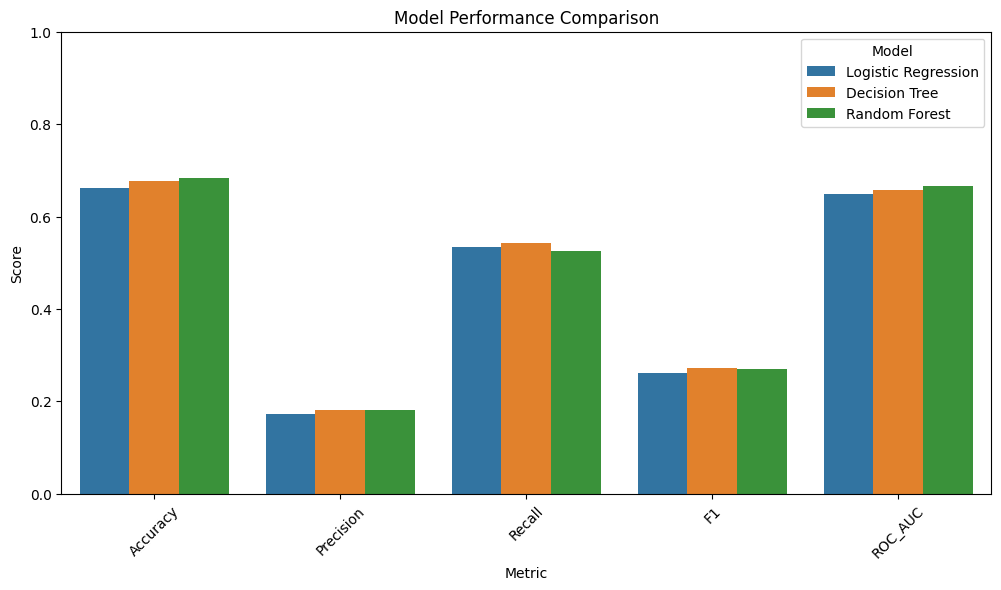

In [ ]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()